In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [6]:
# Celda 1 — Importaciones y configuración
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('insurance.csv')
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
# Celda 2 — Revisión general
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


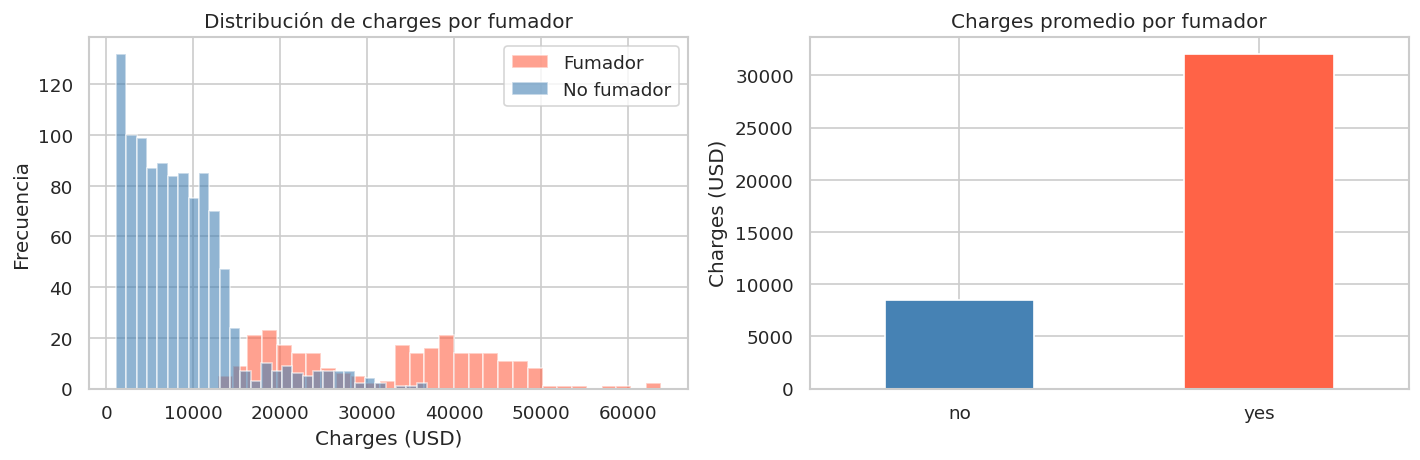

In [10]:
# Celda 3 — Charges por fumador
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma superpuesto: fumador vs no fumador
for smoker, color, label in [('yes', 'tomato', 'Fumador'), ('no', 'steelblue', 'No fumador')]:
    subset = df[df['smoker'] == smoker]['charges']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Distribución de charges por fumador')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Promedio como barras
df.groupby('smoker')['charges'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[1].set_title('Charges promedio por fumador')
axes[1].set_ylabel('Charges (USD)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

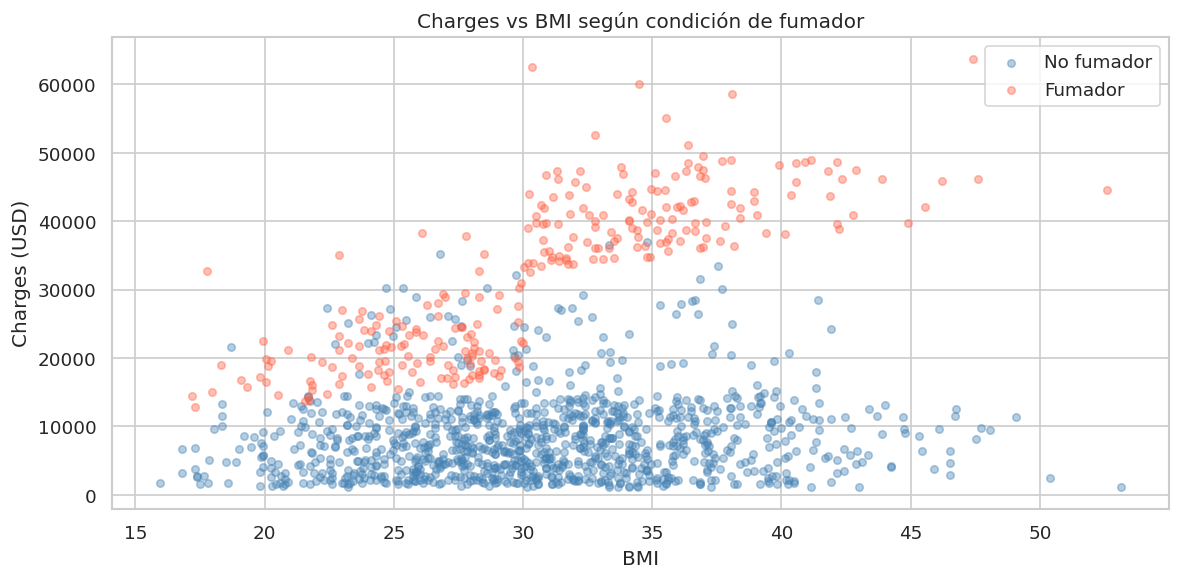

In [11]:
# Celda 4 — Charges vs BMI (scatter por fumador)
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'yes': 'tomato', 'no': 'steelblue'}
for smoker, group in df.groupby('smoker'):
    ax.scatter(group['bmi'], group['charges'],
               alpha=0.4, s=20,
               color=colors[smoker],
               label='Fumador' if smoker == 'yes' else 'No fumador')

ax.set_title('Charges vs BMI según condición de fumador')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges (USD)')
ax.legend()
plt.tight_layout()
plt.show()

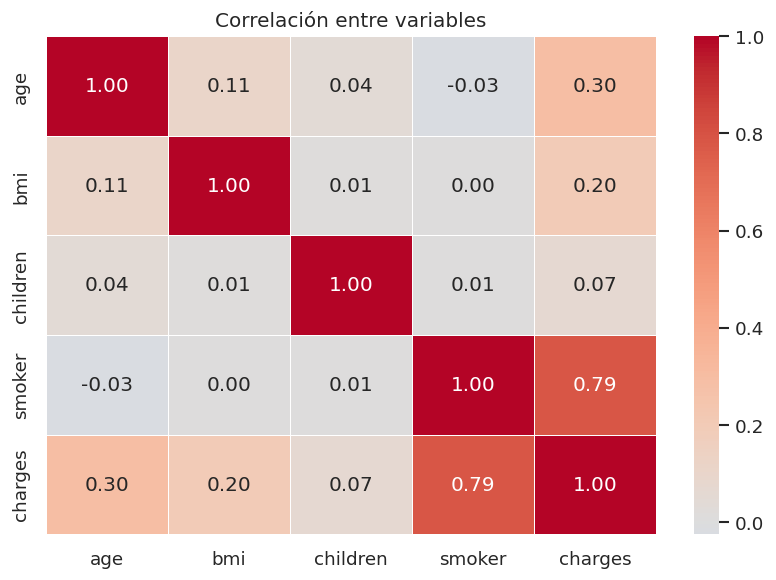

In [12]:
# Celda 5 — Mapa de correlaciones
df_encoded = df.copy()
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})

corr = df_encoded[['age', 'bmi', 'children', 'smoker', 'charges']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre variables')
plt.tight_layout()
plt.show()